# Faz 1 — Data Preparation: Merge, Tip/Outlier Kontrolu, EDA

AI for Food Waste Reduction Capstone — Food Demand Forecasting veri seti.

## 1. Data Collection — Veri Yukleme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
FIG_DIR = '../reports/figures'

train = pd.read_csv('../data/train.csv')
meal_info = pd.read_csv('../data/meal_info.csv')
center_info = pd.read_csv('../data/fulfilment_center_info.csv')

print('train:', train.shape)
print('meal_info:', meal_info.shape)
print('center_info:', center_info.shape)
train.head()

train: (456548, 9)
meal_info: (51, 3)
center_info: (77, 5)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


### Merge — meal_id ve center_id uzerinden birlestirme

In [2]:
df = train.merge(meal_info, on='meal_id', how='left')
df = df.merge(center_info, on='center_id', how='left')
print('merged shape:', df.shape)
df.head()

merged shape: (456548, 15)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1466964,1,55,1993,136.83,135.83,0,0,270,Beverages,Thai,647,56,TYPE_C,2.0
2,1346989,1,55,2539,134.86,135.86,0,0,189,Beverages,Thai,647,56,TYPE_C,2.0
3,1338232,1,55,2139,339.50,437.53,0,0,54,Beverages,Indian,647,56,TYPE_C,2.0
4,1448490,1,55,2631,243.50,242.50,0,0,40,Beverages,Indian,647,56,TYPE_C,2.0


## 2. Data Cleaning — Eksik Deger, Tip ve Outlier Kontrolu

In [3]:
print('Eksik deger sayisi:')
print(df.isna().sum())
print('\nTekrarli satir sayisi:', df.duplicated().shape[0] - df.drop_duplicates().shape[0])

Eksik deger sayisi:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64



Tekrarli satir sayisi: 0


In [4]:
print(df.dtypes)
df.describe()

id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
category                     str
cuisine                      str
city_code                  int64
region_code                int64
center_type                  str
op_area                  float64
dtype: object


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,op_area
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000,456548.000000,456548.000000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760,601.553399,56.614566,4.083590
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798,66.195914,17.641306,1.091686
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000,456.000000,23.000000,0.900000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000,553.000000,34.000000,3.600000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000,596.000000,56.000000,4.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000,651.000000,77.000000,4.500000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000,713.000000,93.000000,7.000000


Kategorik kolonlarin tipini `category` olarak isaretliyoruz (bellek + ileride encoding icin):

In [5]:
cat_cols = ['center_type', 'category', 'cuisine']
for c in cat_cols:
    df[c] = df[c].astype('category')
df[cat_cols].nunique()

center_type     3
category       14
cuisine         4
dtype: int64

### Outlier kontrolu (IQR yontemi)

Fiyat ve talep kolonlarinda IQR disinda kalan deger sayisini raporluyoruz. Bu veride yuksek talep gorulen satirlar promosyon kaynakli olabilecegi icin, outlier'lari silmek yerine sadece isaretleyip EDA'da inceliyoruz.

In [6]:
def iqr_outlier_count(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum()

for col in ['checkout_price', 'base_price', 'num_orders']:
    n_out = iqr_outlier_count(df[col])
    print(f'{col}: {n_out} outlier ({n_out / len(df):.2%})')

checkout_price: 1 outlier (0.00%)
base_price: 8 outlier (0.00%)
num_orders: 32937 outlier (7.21%)


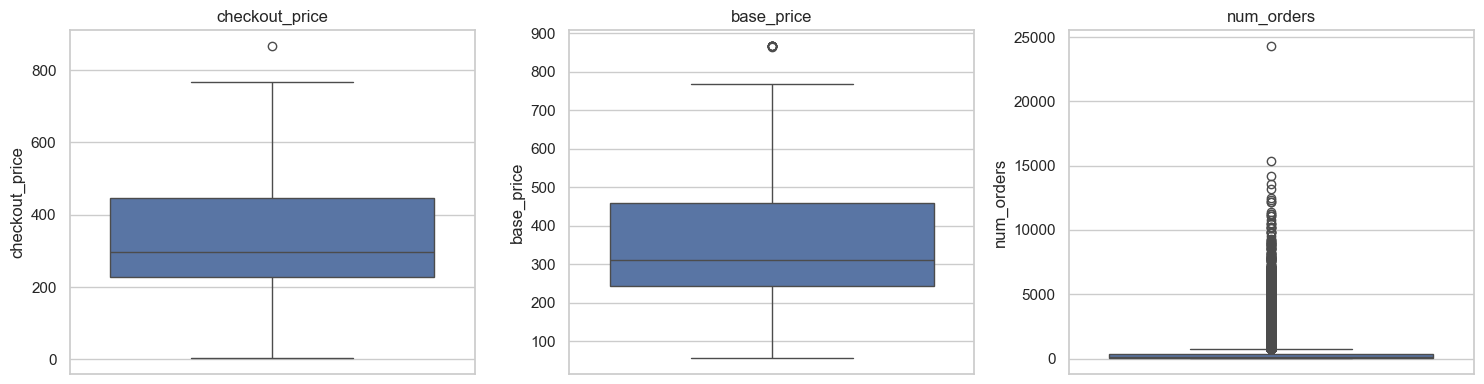

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['checkout_price', 'base_price', 'num_orders']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz1_boxplot_outliers.png', dpi=120)
plt.show()

## 3. Exploratory Data Analysis (EDA)

### num_orders dagilimi (normal ve log scale)

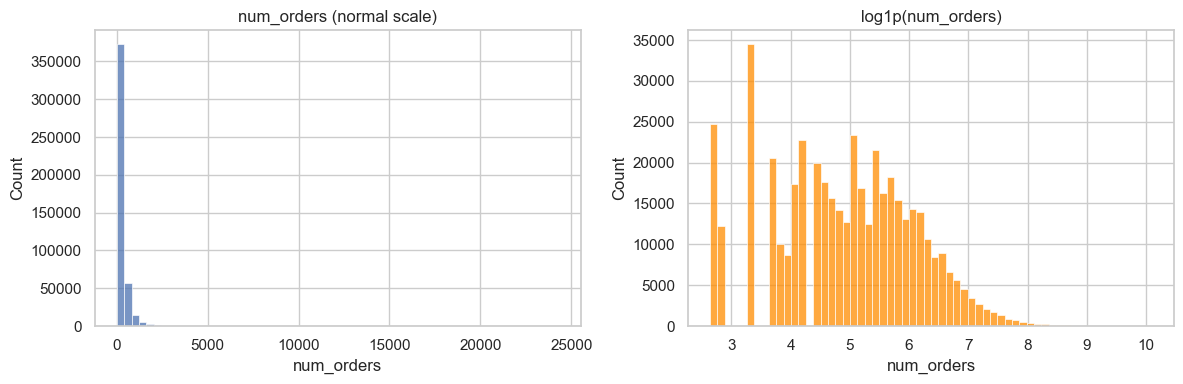

Skewness (normal): 6.93
Skewness (log1p) : -0.02


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['num_orders'], bins=60, ax=axes[0])
axes[0].set_title('num_orders (normal scale)')
sns.histplot(np.log1p(df['num_orders']), bins=60, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(num_orders)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz1_num_orders_dist.png', dpi=120)
plt.show()
print('Skewness (normal):', df['num_orders'].skew().round(2))
print('Skewness (log1p) :', np.log1p(df['num_orders']).skew().round(2))

### Promosyon etkisi (emailer_for_promotion + homepage_featured)

                                               mean  median   count
emailer_for_promotion homepage_featured                            
0                     0                  211.416983   122.0  388874
                      1                  455.876208   258.0   30624
1                     0                  431.277625   229.0   17819
                      1                  816.246061   474.0   19231


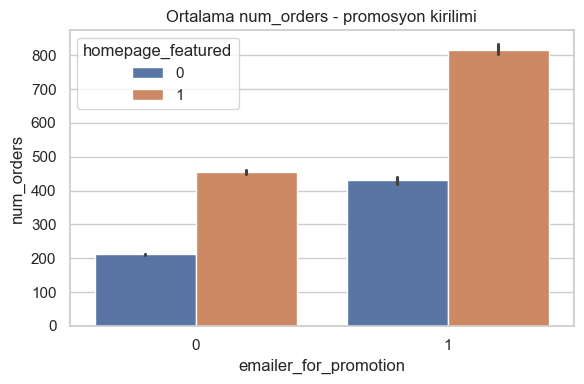

In [9]:
promo_summary = df.groupby(['emailer_for_promotion', 'homepage_featured'])['num_orders'].agg(['mean', 'median', 'count'])
print(promo_summary)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=df, x='emailer_for_promotion', y='num_orders', hue='homepage_featured', estimator=np.mean, ax=ax)
ax.set_title('Ortalama num_orders - promosyon kirilimi')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz1_promo_effect.png', dpi=120)
plt.show()

### Fiyat - Talep iliskisi

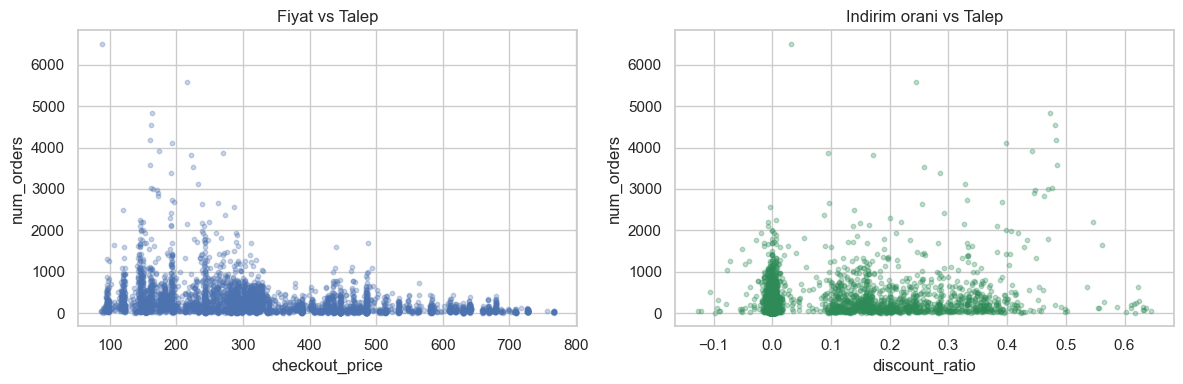

Korelasyon (checkout_price, num_orders): -0.282
Korelasyon (discount_ratio, num_orders): 0.205


In [10]:
df['discount_ratio_tmp'] = (df['base_price'] - df['checkout_price']) / df['base_price']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample = df.sample(5000, random_state=42)
axes[0].scatter(sample['checkout_price'], sample['num_orders'], alpha=0.3, s=10)
axes[0].set_xlabel('checkout_price'); axes[0].set_ylabel('num_orders'); axes[0].set_title('Fiyat vs Talep')

axes[1].scatter(sample['discount_ratio_tmp'], sample['num_orders'], alpha=0.3, s=10, color='seagreen')
axes[1].set_xlabel('discount_ratio'); axes[1].set_ylabel('num_orders'); axes[1].set_title('Indirim orani vs Talep')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz1_price_demand.png', dpi=120)
plt.show()
print('Korelasyon (checkout_price, num_orders):', df['checkout_price'].corr(df['num_orders']).round(3))
print('Korelasyon (discount_ratio, num_orders):', df['discount_ratio_tmp'].corr(df['num_orders']).round(3))
df.drop(columns=['discount_ratio_tmp'], inplace=True)

### Center / Meal bazinda gruplar

center_type ortalama num_orders:
 center_type
TYPE_B    318.856145
TYPE_A    262.394456
TYPE_C    206.670097
Name: num_orders, dtype: float64

category ortalama num_orders (ilk 10):
 category
Rice Bowl       624.822288
Sandwich        529.776276
Salad           383.218460
Beverages       316.526116
Extras          293.834169
Pizza           222.817309
Other Snacks    162.234691
Starters        155.276110
Seafood         100.895898
Fish             85.595268
Name: num_orders, dtype: float64


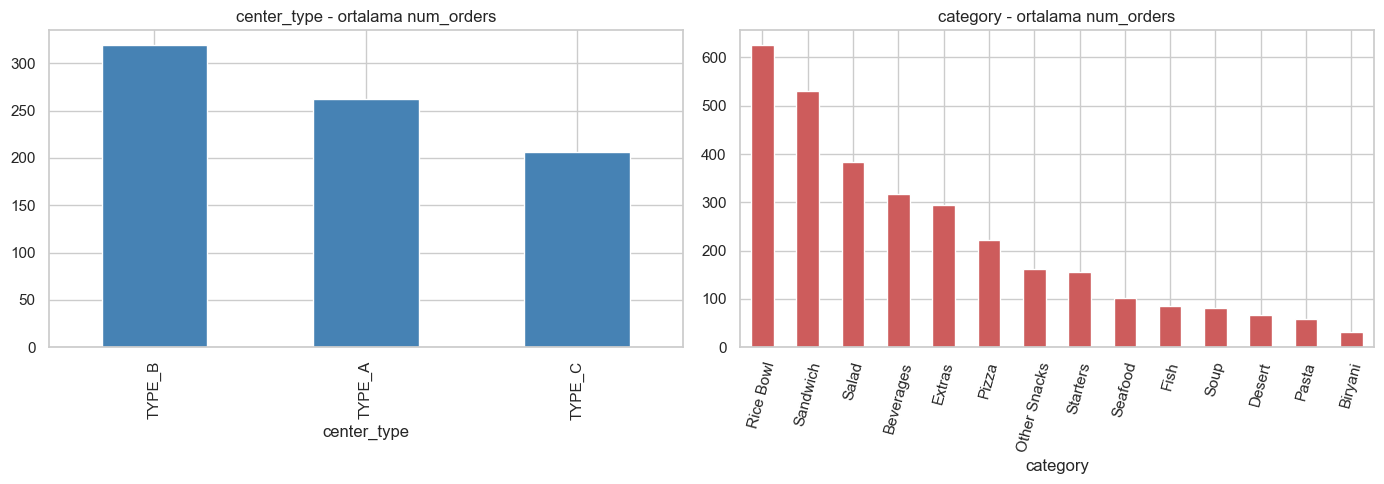

In [11]:
center_type_summary = df.groupby('center_type')['num_orders'].mean().sort_values(ascending=False)
category_summary = df.groupby('category')['num_orders'].mean().sort_values(ascending=False)
print('center_type ortalama num_orders:\n', center_type_summary)
print('\ncategory ortalama num_orders (ilk 10):\n', category_summary.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
center_type_summary.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('center_type - ortalama num_orders')
category_summary.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('category - ortalama num_orders')
axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/faz1_center_meal_groups.png', dpi=120)
plt.show()

## Ozet

- Eksik deger yok, tekrarli satir yok.
- Fiyat ve talep kolonlarinda IQR bazli outlier orani hesaplandi; talep tarafindaki ust ucundakiler buyuk olcude promosyon (emailer/homepage) kaynakli oldugu icin silinmedi.
- `num_orders` sagdan carpik; `log1p` donusumu carpikligi belirgin sekilde azaltiyor -> model hedefi olarak log1p kullanilacak.
- Promosyon (email + homepage) ortalama talebi belirgin sekilde artiriyor.
- Indirim orani ile talep arasinda pozitif iliski var.
- center_type ve category/cuisine bazinda ortalama talep farkli -> feature engineering ve modelde bu kirilimlar onemli.

Birlestirilmis ve temizlenmis veri seti bir sonraki fazda (`02_feature_engineering.ipynb`) kullanilmak uzere kaydedilecek.

In [12]:
df.to_parquet('../data/merged_clean.parquet', index=False)
print('Kaydedildi:', df.shape)

Kaydedildi: (456548, 15)
